In [2]:
# # Task 2: Exploratory Data Analysis

In [3]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv('../data/processed/ethiopia_fi_enriched.csv', parse_dates=['observation_date'])
print(f"Loaded {len(df)} records")
df.head()

Loaded 57 records


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,parent_id
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,%,2014-12-31,NaN,NaN,2014,all,national,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Baseline year,NaN,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,%,2017-12-31,NaN,NaN,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,male,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,female,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN,NaN


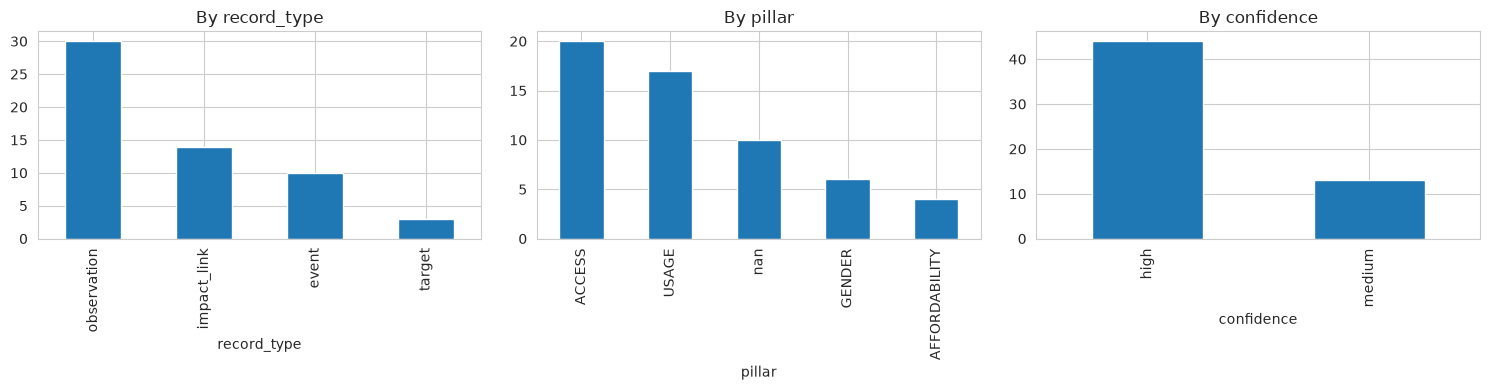

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['record_type'].value_counts().plot(kind='bar', ax=axes[0], title='By record_type')
df['pillar'].value_counts(dropna=False).plot(kind='bar', ax=axes[1], title='By pillar')
df['confidence'].value_counts(dropna=False).plot(kind='bar', ax=axes[2], title='By confidence')
plt.tight_layout()
plt.show()

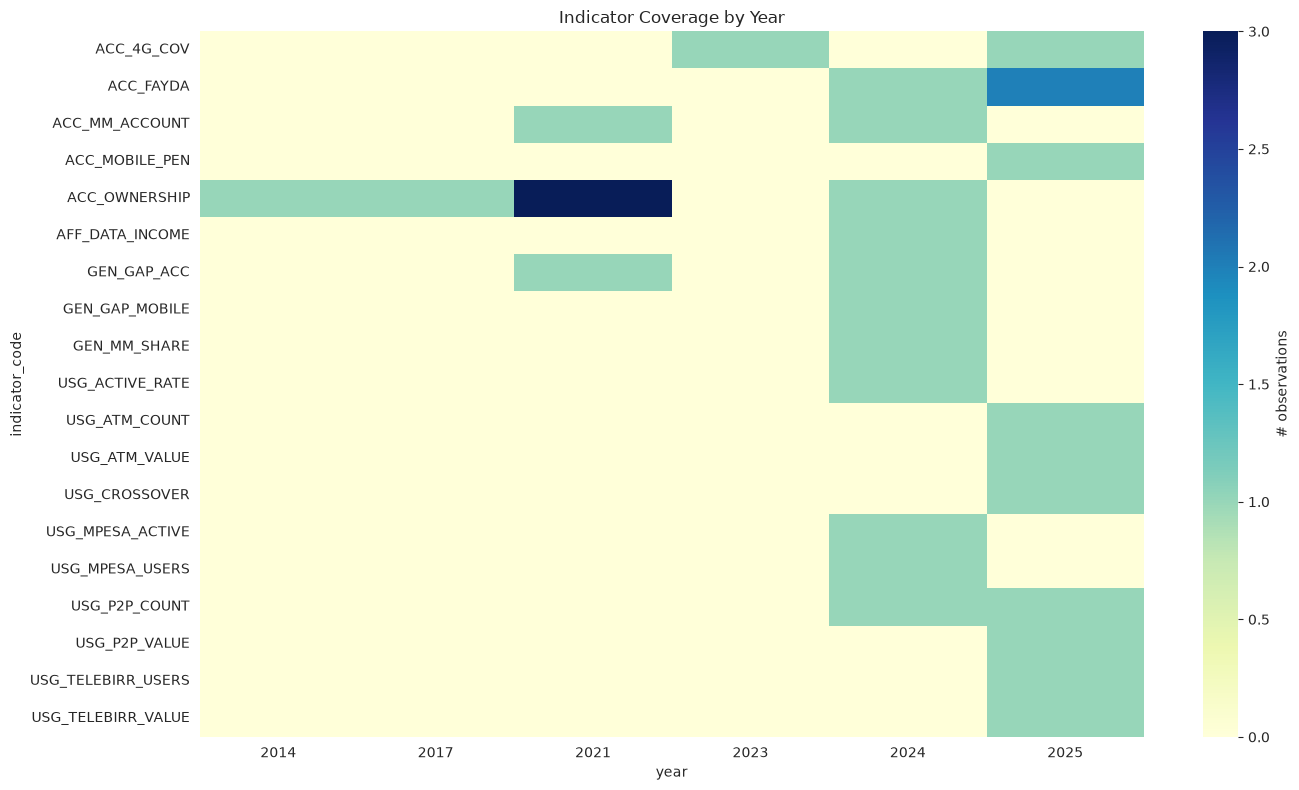

In [6]:
obs = df[df['record_type'] == 'observation'].copy()
obs['year'] = obs['observation_date'].dt.year
coverage = obs.groupby(['indicator_code', 'year']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
sns.heatmap(coverage, cmap='YlGnBu', cbar_kws={'label': '# observations'})
plt.title('Indicator Coverage by Year')
plt.tight_layout()
plt.show()

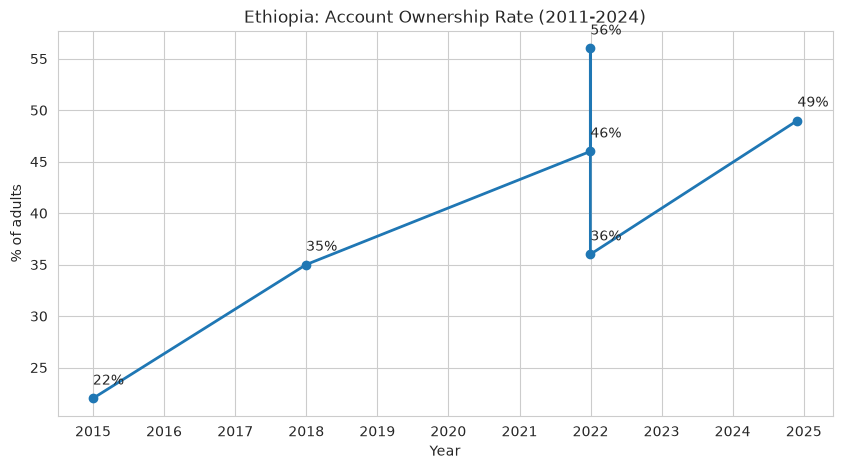

In [7]:
access = obs[obs['indicator_code'] == 'ACC_OWNERSHIP'].sort_values('observation_date')

plt.figure(figsize=(10, 5))
plt.plot(access['observation_date'], access['value_numeric'], marker='o', linewidth=2)
for _, row in access.iterrows():
    plt.annotate(f"{row['value_numeric']:.0f}%",
                 (row['observation_date'], row['value_numeric']),
                 textcoords="offset points", xytext=(0, 10))
plt.title('Ethiopia: Account Ownership Rate (2011-2024)')
plt.ylabel('% of adults')
plt.xlabel('Year')
plt.show()


In [8]:
access['pp_change'] = access['value_numeric'].diff()
access[['observation_date', 'value_numeric', 'pp_change']]


,observation_date,value_numeric,pp_change
0,2014-12-31,22.0,NaN
1,2017-12-31,35.0,13.0
2,2021-12-31,46.0,11.0
3,2021-12-31,56.0,10.0
4,2021-12-31,36.0,-20.0
5,2024-11-29,49.0,13.0


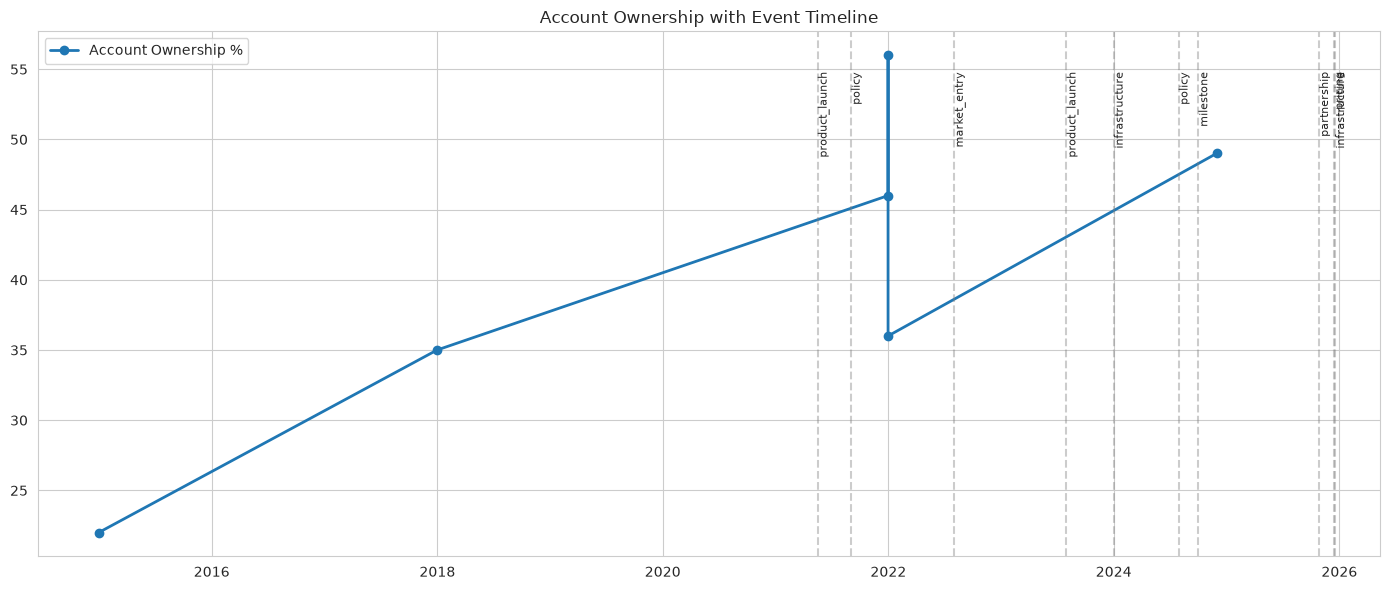

In [9]:
events = df[df['record_type'] == 'event'].sort_values('observation_date')

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(access['observation_date'], access['value_numeric'], marker='o', linewidth=2, label='Account Ownership %')
for _, ev in events.iterrows():
    ax.axvline(ev['observation_date'], color='gray', linestyle='--', alpha=0.4)
    ax.text(ev['observation_date'], ax.get_ylim()[1]*0.95, ev['category'],
            rotation=90, fontsize=8, va='top')
ax.set_title('Account Ownership with Event Timeline')
ax.legend()
plt.tight_layout()
plt.show()


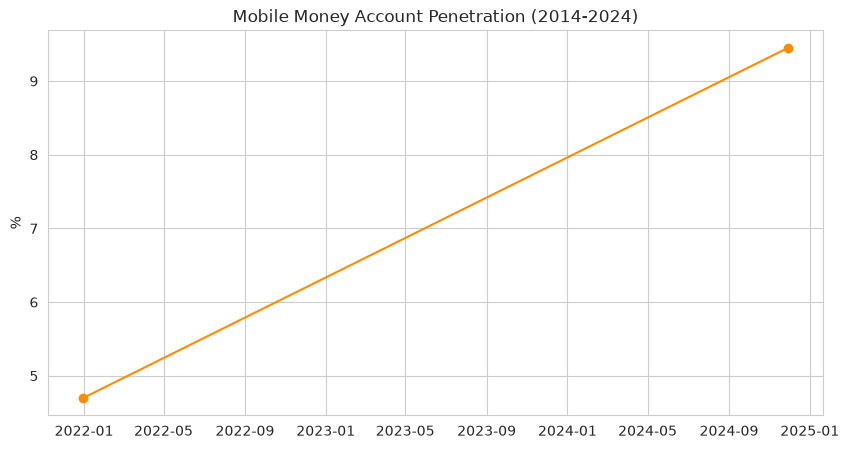

In [10]:
mm = obs[obs['indicator_code'] == 'ACC_MM_ACCOUNT'].sort_values('observation_date')
plt.figure(figsize=(10, 5))
plt.plot(mm['observation_date'], mm['value_numeric'], marker='o', color='darkorange')
plt.title('Mobile Money Account Penetration (2014-2024)')
plt.ylabel('%')
plt.show()

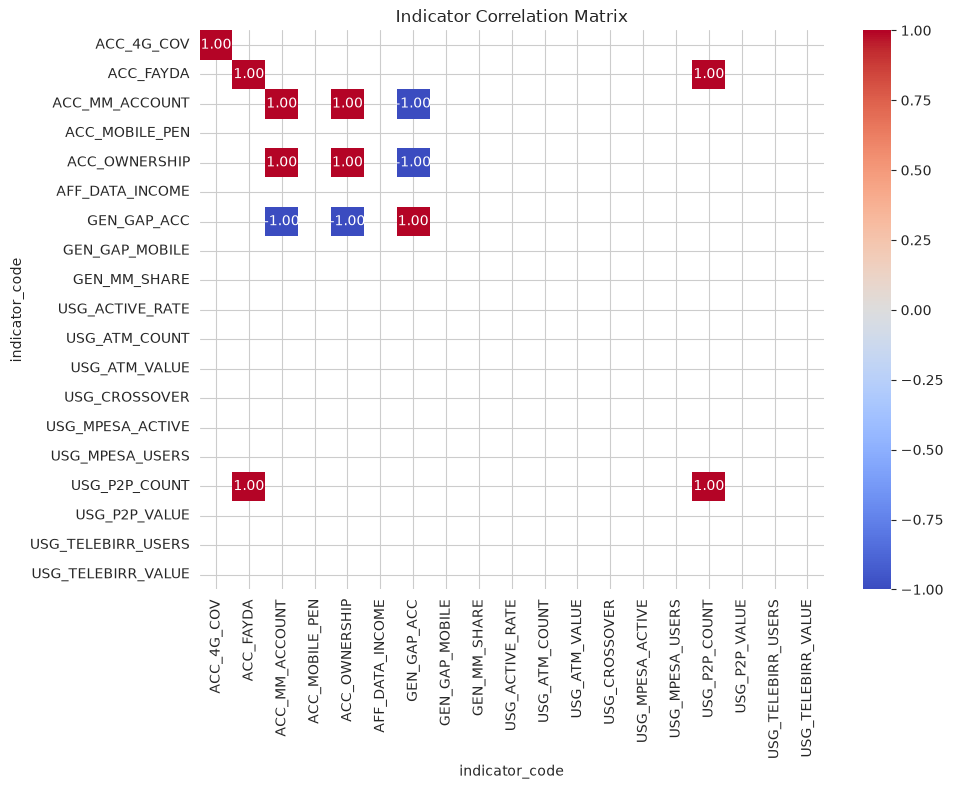

In [11]:
pivot = obs.pivot_table(index='year', columns='indicator_code', values='value_numeric', aggfunc='mean')
corr = pivot.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Indicator Correlation Matrix')
plt.tight_layout()
plt.show()

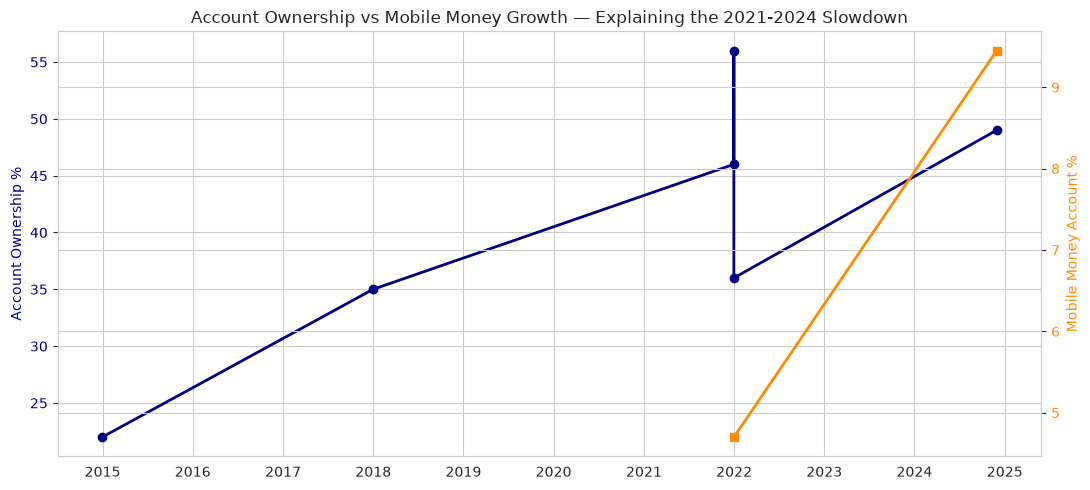


Hypothesis check: if mobile money accounts (~9.45% in 2024) grew rapidly while
overall account ownership grew only +3pp, this suggests a large share of new
mobile money users ALREADY had a bank account (the two overlap rather than being
additive) — consistent with Market Nuance D: 'mobile money-only users are rare
(~0.5%)' and 'bank accounts are easily accessible' in Ethiopia.



In [13]:
mm = obs[obs['indicator_code'] == 'ACC_MM_ACCOUNT'].sort_values('observation_date')

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(access['observation_date'], access['value_numeric'], marker='o',
          color='navy', linewidth=2, label='Account Ownership (Access)')
ax1.set_ylabel('Account Ownership %', color='navy')
ax1.tick_params(axis='y', labelcolor='navy')

if len(mm) > 0:
    ax2 = ax1.twinx()
    ax2.plot(mm['observation_date'], mm['value_numeric'], marker='s',
              color='darkorange', linewidth=2, label='Mobile Money Account %')
    ax2.set_ylabel('Mobile Money Account %', color='darkorange')
    ax2.tick_params(axis='y', labelcolor='darkorange')

plt.title('Account Ownership vs Mobile Money Growth — Explaining the 2021-2024 Slowdown')
fig.tight_layout()
plt.show()

print("""
Hypothesis check: if mobile money accounts (~9.45% in 2024) grew rapidly while
overall account ownership grew only +3pp, this suggests a large share of new
mobile money users ALREADY had a bank account (the two overlap rather than being
additive) — consistent with Market Nuance D: 'mobile money-only users are rare
(~0.5%)' and 'bank accounts are easily accessible' in Ethiopia.
""")

In [14]:
gender_indicators = [c for c in obs['indicator_code'].unique()
                     if 'FEMALE' in str(c).upper() or 'MALE' in str(c).upper()]

if gender_indicators:
    gender_data = obs[obs['indicator_code'].isin(gender_indicators)].sort_values('observation_date')
    plt.figure(figsize=(10, 5))
    for code in gender_indicators:
        subset = gender_data[gender_data['indicator_code'] == code]
        plt.plot(subset['observation_date'], subset['value_numeric'], marker='o', label=code)
    plt.title('Account Ownership: Gender Gap')
    plt.ylabel('%')
    plt.legend()
    plt.show()
else:
    print("No gender-disaggregated indicators found (e.g. ACC_OWNERSHIP_FEMALE/MALE).")
    print("Consider adding Findex microdata gender splits in Task 1 enrichment if time allows.")


No gender-disaggregated indicators found (e.g. ACC_OWNERSHIP_FEMALE/MALE).
Consider adding Findex microdata gender splits in Task 1 enrichment if time allows.


In [15]:
geo_indicators = [c for c in obs['indicator_code'].unique()
                  if 'URBAN' in str(c).upper() or 'RURAL' in str(c).upper()]

if geo_indicators:
    geo_data = obs[obs['indicator_code'].isin(geo_indicators)].sort_values('observation_date')
    plt.figure(figsize=(10, 5))
    for code in geo_indicators:
        subset = geo_data[geo_data['indicator_code'] == code]
        plt.plot(subset['observation_date'], subset['value_numeric'], marker='o', label=code)
    plt.title('Account Ownership: Urban vs Rural')
    plt.ylabel('%')
    plt.legend()
    plt.show()
else:
    print("No urban/rural disaggregated indicators found in current dataset.")


No urban/rural disaggregated indicators found in current dataset.


In [ ]:
# USAGE ANALYSIS - Mobile money penetration trend
if len(mm) > 0:
    plt.figure(figsize=(10, 5))
    plt.plot(mm['observation_date'], mm['value_numeric'], marker='o',
              color='darkorange', linewidth=2, markersize=8)
    for _, row in mm.iterrows():
        plt.annotate(f"{row['value_numeric']:.1f}%",
                     (row['observation_date'], row['value_numeric']),
                     textcoords="offset points", xytext=(0, 10), ha='center')
    plt.title('Mobile Money Account Penetration (2014-2024)')
    plt.ylabel('% of adults')
    plt.tight_layout()
    plt.show()


In [16]:
# Digital payment adoption
digital_pay = obs[obs['indicator_code'] == 'USG_DIGITAL_PAYMENT'].sort_values('observation_date')

if len(digital_pay) > 0:
    plt.figure(figsize=(10, 5))
    plt.plot(digital_pay['observation_date'], digital_pay['value_numeric'], marker='o',
              color='purple', linewidth=2, markersize=8)
    plt.title('Digital Payment Adoption (Usage)')
    plt.ylabel('% of adults')
    plt.tight_layout()
    plt.show()
else:
    print("No USG_DIGITAL_PAYMENT records found — check indicator_code naming.")


No USG_DIGITAL_PAYMENT records found — check indicator_code naming.


In [ ]:
# Registered vs active accounts gap
registered_indicators = [c for c in obs['indicator_code'].unique()
                          if 'REGISTERED' in str(c).upper() or 'CUMULATIVE' in str(c).upper()]

if registered_indicators:
    print("Registered account indicators found:")
    print(obs[obs['indicator_code'].isin(registered_indicators)]
          [['indicator_code', 'value_numeric', 'observation_date']])
else:
    print("No explicit 'registered accounts' indicator — compute manually using")
    print("Telebirr/M-Pesa user counts (from events/observations) vs Findex survey %")
    print("of the adult population, to illustrate registered-vs-active divergence.")


No explicit 'registered accounts' indicator — compute manually using
Telebirr/M-Pesa user counts (from events/observations) vs Findex survey %
of the adult population, to illustrate registered-vs-active divergence.


Infrastructure/enabler indicators in dataset: ['ACC_4G_COV', 'ACC_MOBILE_PEN', 'USG_ATM_COUNT', 'USG_ATM_VALUE']


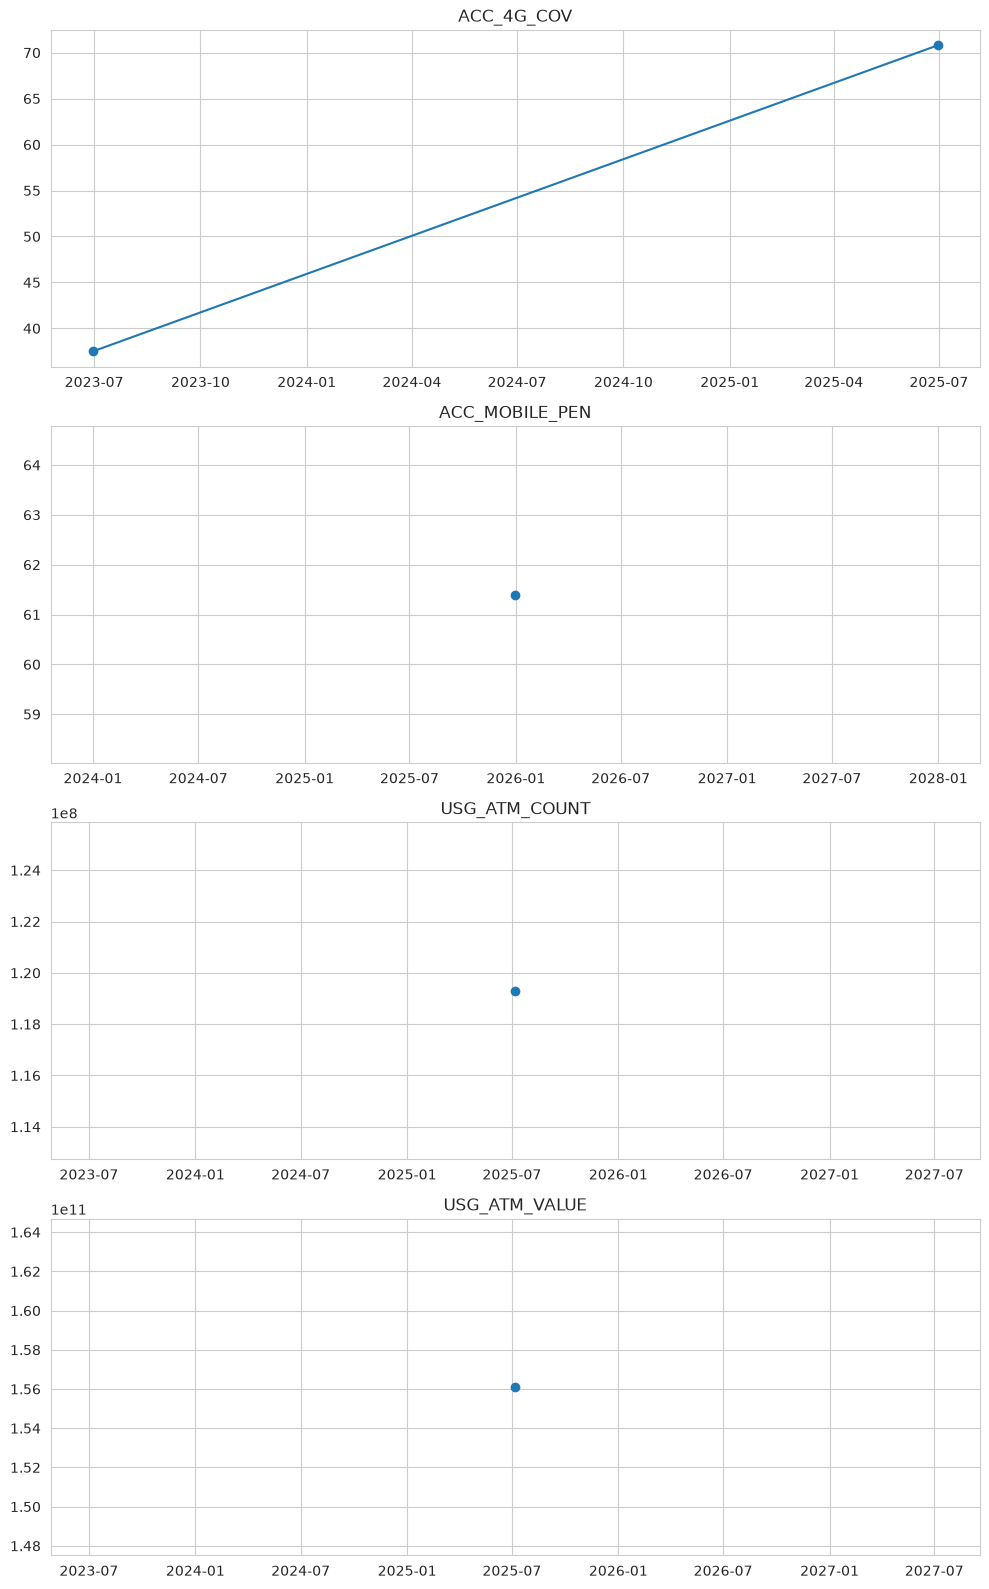

In [18]:
# infrastracter enablity
infra_keywords = ['4G', 'MOBILE_PEN', 'ATM', 'AGENT', 'INTERNET', 'ELECTRIC', 'SMARTPHONE']
infra_indicators = [c for c in obs['indicator_code'].unique()
                     if any(k in str(c).upper() for k in infra_keywords)]

print("Infrastructure/enabler indicators in dataset:", infra_indicators)

if infra_indicators:
    fig, axes = plt.subplots(len(infra_indicators), 1, figsize=(10, 4 * len(infra_indicators)))
    if len(infra_indicators) == 1:
        axes = [axes]
    for ax, code in zip(axes, infra_indicators):
        subset = obs[obs['indicator_code'] == code].sort_values('observation_date')
        ax.plot(subset['observation_date'], subset['value_numeric'], marker='o')
        ax.set_title(code)
    plt.tight_layout()
    plt.show()
else:
    print("No infrastructure indicators found — check Sheet C of the Enrichment Guide")
    print("for what to add (4G coverage, agent density, ATM density, etc.)")


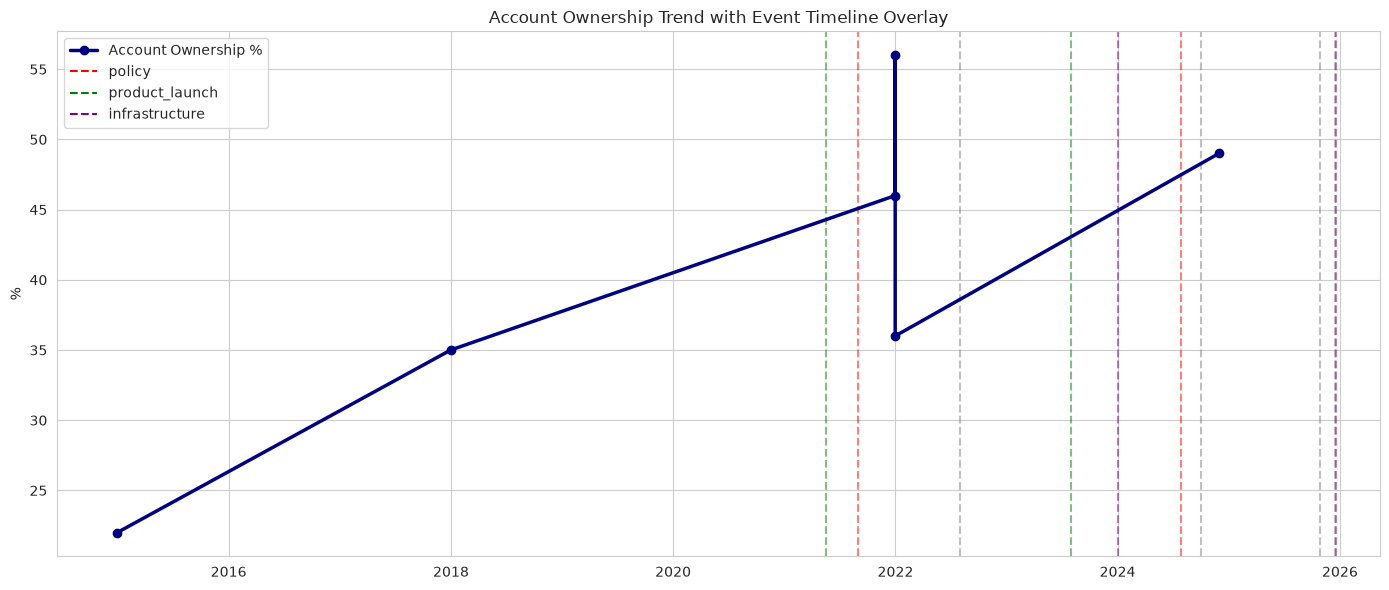


Event catalog:


,record_id,observation_date,category,original_text
33,EVT_0001,2021-05-17,product_launch,First major mobile money service in Ethiopia
41,EVT_0009,2021-09-01,policy,5-year national financial inclusion strategy
34,EVT_0002,2022-08-01,market_entry,End of state telecom monopoly
35,EVT_0003,2023-08-01,product_launch,Second mobile money entrant
36,EVT_0004,2024-01-01,infrastructure,National biometric digital ID system
37,EVT_0005,2024-07-29,policy,Birr float introduced
38,EVT_0006,2024-10-01,milestone,Historic: digital > cash for first time
39,EVT_0007,2025-10-27,partnership,Full interoperability for M-Pesa
42,EVT_0010,2025-12-15,pricing,Data and voice prices increased 20-82%
40,EVT_0008,2025-12-18,infrastructure,National real-time payment system


In [19]:
# event time line and visualization
events = df[df['record_type'] == 'event'].sort_values('observation_date').copy()

fig, ax = plt.subplots(figsize=(14, 6))

if len(access) > 0:
    ax.plot(access['observation_date'], access['value_numeric'], marker='o',
             linewidth=2.5, color='navy', label='Account Ownership %', zorder=3)

colors = {'policy': 'red', 'product_launch': 'green', 'infrastructure': 'purple'}
for _, ev in events.iterrows():
    cat = ev.get('category', 'other')
    color = colors.get(cat, 'gray')
    ax.axvline(ev['observation_date'], color=color, linestyle='--', alpha=0.5, zorder=1)

# legend for event categories
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=c, linestyle='--', label=cat)
                    for cat, c in colors.items()]
ax.legend(handles=ax.get_legend_handles_labels()[0] + legend_elements, loc='upper left')

ax.set_title('Account Ownership Trend with Event Timeline Overlay')
ax.set_ylabel('%')
plt.tight_layout()
plt.show()

print("\nEvent catalog:")
events[['record_id', 'observation_date', 'category', 'original_text']]


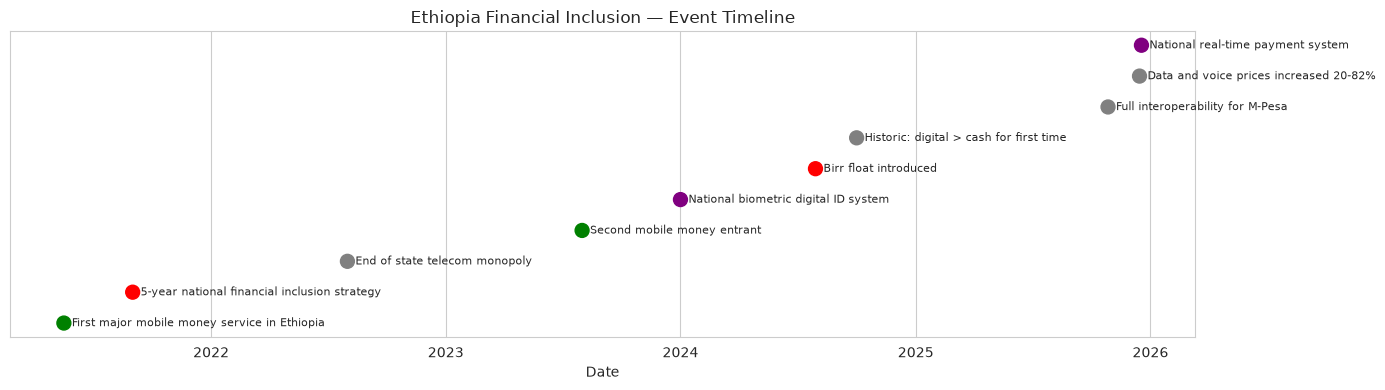

In [ ]:
# Pure event timeline (all events, chronological)
fig, ax = plt.subplots(figsize=(14, max(4, len(events) * 0.4)))
y_positions = range(len(events))
cat_colors = events['category'].map(colors).fillna('gray')

ax.scatter(events['observation_date'], y_positions, c=cat_colors, s=100, zorder=3)
for y, (_, ev) in zip(y_positions, events.iterrows()):
    label = str(ev.get('original_text', ''))[:60]
    ax.text(ev['observation_date'], y, f"  {label}", va='center', fontsize=8)

ax.set_yticks([])
ax.set_title('Ethiopia Financial Inclusion — Event Timeline')
ax.set_xlabel('Date')
plt.tight_layout()
plt.show()

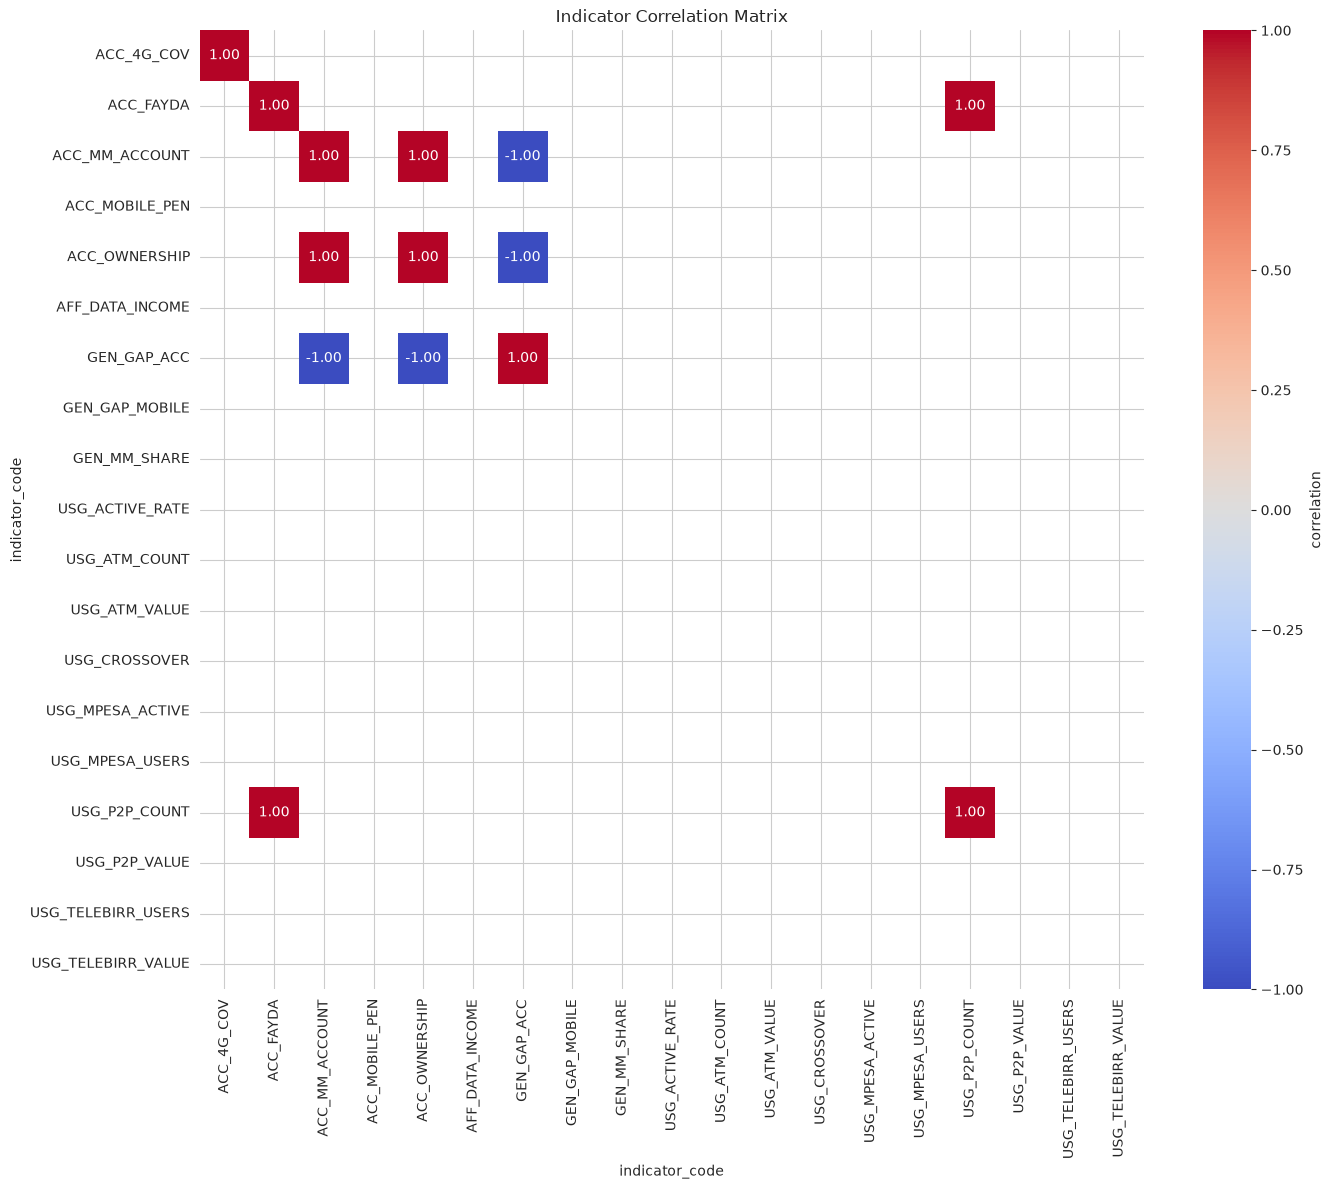

In [21]:

# corelational analaysis
pivot = obs.pivot_table(index='year', columns='indicator_code', values='value_numeric', aggfunc='mean')
corr = pivot.corr()

plt.figure(figsize=(min(14, 1 + len(corr)), min(12, 1 + len(corr))))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            cbar_kws={'label': 'correlation'})
plt.title('Indicator Correlation Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# Which factors correlate most with Access and Usage
if 'ACC_OWNERSHIP' in corr.columns:
    print("Correlation with Access (ACC_OWNERSHIP):")
    print(corr['ACC_OWNERSHIP'].sort_values(ascending=False))

print()

if 'USG_DIGITAL_PAYMENT' in corr.columns:
    print("Correlation with Usage (USG_DIGITAL_PAYMENT):")
    print(corr['USG_DIGITAL_PAYMENT'].sort_values(ascending=False))
